# 🚀 머신러닝 실습 : 고객 구매 데이터로 성별 예측 모델링 (분류 문제)
- 백화점 고객의 1년 간 구매 데이터
- 고객 3,500명에 대한 학습용 데이터를 이용하여 성별예측 모형 생성
- 모델의 성능은 자유롭게 측정

[실습 프로세스]
1. 데이터 불러오기
2. 데이터 탐색
3. 데이터 전처리
4. 학습/테스트 데이터 분리
5. 모델 선택 및 학습
6. 예측 및 평가

위의 프로세스에 따라 한단계씩 과정을 진행하겠습니다.
LogisticRegression 로 기준 예측 성능을 확인하고, 평가지표는 정확도, 정밀도, 재현율, f1, confusion_matrix를 사용합니다. 이후 DecisionTree, RandomForest, XGBoost 로 모델 성능을 비교하겠습니다.

[주의사항]
코드 작성 시 지나치게 복잡하지 않고 최대한 심플(예를들어, 람다나 3항연산은 배제)한 코드를 선호합니다.
구조 변경이나, 복잡한 제어문, 함수정의, ml 모델의 함수호출 등에는 주석을 추가하세요.
각 단계마다 실행결과를 분석해서 노트북셀로 정리하려고 합니다.
- 주석은 이해하기 쉬운 표현을 사용하고,
- 결과 분석 문장ㅇ느 마크다운 형식으로 작성하세요(h2, h3는 사용금지)
- 모델링 코드는 ipynb 형식입니다.


# 0. 라이브러리 불러오기

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings(action='ignore')

# 1. 데이터 불러오기
- 인코딩 방식은 'euc-kr'  활용
- 데이터 출처 : 한국데이터산업진흥원 빅데이터분석기사 실기 공개 예시 문항
  - 독립 변수 데이터셋 : ./data/X.csv
  - 종속 변수 데이터셋 : ./data/y.csv

CSV 파일을 pandas로 읽어옴

In [51]:
# import os
# # 노트북 파일이 있는 폴더로 이동 (예시)
# os.chdir(r'C:\githome\hipython_rep')

# # 변경 후 확인
# print("변경 후:", os.getcwd())

In [52]:
X = pd.read_csv('./data/X.csv', encoding='euc-kr')
y = pd.read_csv('./data/y.csv', encoding='euc-kr')

# 2. 데이터 탐색하기
- 데이터를 이해하기위한 탐색 과정 수행
1. 데이터의 상위 몇 개 행을 출력하여 전체 구조 확인
2. 데이터의 요약 정보나 통계 정보를 출력해 변수들의 유형과 분포 확인

In [53]:
# 1. 전체 구조 확인

print("▶ X 데이터 상위 5개 행:")
display(X.head())  # 일반 환경일 경우 print(X.head()) 사용

print("\n▶ y 데이터 상위 5개 행:")
display(y.head())

▶ X 데이터 상위 5개 행:


,cust_id,총구매액,최대구매액,환불금액,주구매상품,주구매지점,내점일수,내점당구매건수,주말방문비율,구매주기
0,0,68282840,11264000,6860000.0,기타,강남점,19,3.894737,0.527027,17
1,1,2136000,2136000,300000.0,스포츠,잠실점,2,1.500000,0.000000,1
2,2,3197000,1639000,NaN,남성 캐주얼,관악점,2,2.000000,0.000000,1
3,3,16077620,4935000,NaN,기타,광주점,18,2.444444,0.318182,16
4,4,29050000,24000000,NaN,보석,본 점,2,1.500000,0.000000,85



▶ y 데이터 상위 5개 행:


,cust_id,gender
0,0,0
1,1,0
2,2,1
3,3,1
4,4,0


In [54]:
# 2. 데이터의 요약 및 통계 정보 (유형, 결측치, 분포)

# (1) 요약 정보
print("\n▶ X 데이터 요약 정보 (info):")
X.info()
print("\n▶ y 데이터 요약 정보 (info):")
y.info()


▶ X 데이터 요약 정보 (info):
<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cust_id  3500 non-null   int64  
 1   총구매액     3500 non-null   int64  
 2   최대구매액    3500 non-null   int64  
 3   환불금액     1205 non-null   float64
 4   주구매상품    3500 non-null   str    
 5   주구매지점    3500 non-null   str    
 6   내점일수     3500 non-null   int64  
 7   내점당구매건수  3500 non-null   float64
 8   주말방문비율   3500 non-null   float64
 9   구매주기     3500 non-null   int64  
dtypes: float64(3), int64(5), str(2)
memory usage: 273.6 KB

▶ y 데이터 요약 정보 (info):
<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   cust_id  3500 non-null   int64
 1   gender   3500 non-null   int64
dtypes: int64(2)
memory usage: 54.8 KB


In [55]:
# (2) 기초 통계량 (수치형 데이터의 평균, 표준편차, 최소/최대값, 4분위수 등)
print("\n▶ X 데이터 수치형 변수 기초 통계량 (describe):")
display(X.describe())
print("\n▶ y 데이터 수치형 변수 기초 통계량 (describe):")
display(y.describe())


▶ X 데이터 수치형 변수 기초 통계량 (describe):


,cust_id,총구매액,최대구매액,환불금액,내점일수,내점당구매건수,주말방문비율,구매주기
count,3500.000000,3.500000e+03,3.500000e+03,1.205000e+03,3500.000000,3500.000000,3500.000000,3500.000000
mean,1749.500000,9.191925e+07,1.966424e+07,2.407822e+07,19.253714,2.834963,0.307246,20.958286
std,1010.507298,1.635065e+08,3.199235e+07,4.746453e+07,27.174942,1.912368,0.289752,24.748682
min,0.000000,-5.242152e+07,-2.992000e+06,5.600000e+03,1.000000,1.000000,0.000000,0.000000
25%,874.750000,4.747050e+06,2.875000e+06,2.259000e+06,2.000000,1.666667,0.027291,4.000000
50%,1749.500000,2.822270e+07,9.837000e+06,7.392000e+06,8.000000,2.333333,0.256410,13.000000
75%,2624.250000,1.065079e+08,2.296250e+07,2.412000e+07,25.000000,3.375000,0.448980,28.000000
max,3499.000000,2.323180e+09,7.066290e+08,5.637530e+08,285.000000,22.083333,1.000000,166.000000



▶ y 데이터 수치형 변수 기초 통계량 (describe):


,cust_id,gender
count,3500.000000,3500.000000
mean,1749.500000,0.376000
std,1010.507298,0.484449
min,0.000000,0.000000
25%,874.750000,0.000000
50%,1749.500000,0.000000
75%,2624.250000,1.000000
max,3499.000000,1.000000


In [56]:
# (3) 각 컬럼별 결측치(NaN) 총합
print("\n▶ X 데이터 컬럼별 결측치 개수:")
print(X.isnull().sum())


▶ X 데이터 컬럼별 결측치 개수:
cust_id       0
총구매액          0
최대구매액         0
환불금액       2295
주구매상품         0
주구매지점         0
내점일수          0
내점당구매건수       0
주말방문비율        0
구매주기          0
dtype: int64


# 3. 데이터 전처리
- 전처리를 통해 머신러닝에 사용할 수 있는 형태의 데이터 준비

In [57]:
# 라이브러리 호출
from sklearn.preprocessing import LabelEncoder, StandardScaler # for 인코딩, 스케일링

## 'cust_id' 컬럼 제거 
- 'cust_id'를 수치형 변수로 받아들이면 결과 왜곡
->  컬럼 제거

In [58]:
X.drop('cust_id', axis=1, inplace=True)

print("▶ 'cust_id' 제거 후 X 데이터 확인:")
display(X.head(1))

▶ 'cust_id' 제거 후 X 데이터 확인:


,총구매액,최대구매액,환불금액,주구매상품,주구매지점,내점일수,내점당구매건수,주말방문비율,구매주기
0,68282840,11264000,6860000.0,기타,강남점,19,3.894737,0.527027,17


## 결측치 처리 > 0
  - 결측치를 0으로 채워넣음

In [59]:
# X['환불금액'].isnull().head()
X['환불금액'] = X['환불금액'].fillna(0)
X['환불금액'].head(5)

0    6860000.0
1     300000.0
2          0.0
3          0.0
4          0.0
Name: 환불금액, dtype: float64

## 인코딩
- 문자형 범주 데이터('주구매상품', '주구매지점'를 숫자로 바꿔줌

In [60]:
encoder = LabelEncoder()

str_col = ['주구매상품', '주구매지점']
for col in str_col:
  X[col] = encoder.fit_transform(X[col])

display(X.head())

X.info() 

,총구매액,최대구매액,환불금액,주구매상품,주구매지점,내점일수,내점당구매건수,주말방문비율,구매주기
0,68282840,11264000,6860000.0,5,0,19,3.894737,0.527027,17
1,2136000,2136000,300000.0,21,19,2,1.500000,0.000000,1
2,3197000,1639000,0.0,6,1,2,2.000000,0.000000,1
3,16077620,4935000,0.0,5,2,18,2.444444,0.318182,16
4,29050000,24000000,0.0,15,8,2,1.500000,0.000000,85


<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   총구매액     3500 non-null   int64  
 1   최대구매액    3500 non-null   int64  
 2   환불금액     3500 non-null   float64
 3   주구매상품    3500 non-null   int64  
 4   주구매지점    3500 non-null   int64  
 5   내점일수     3500 non-null   int64  
 6   내점당구매건수  3500 non-null   float64
 7   주말방문비율   3500 non-null   float64
 8   구매주기     3500 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 246.2 KB


## 데이터 분할

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

In [62]:
X_train.head()

,총구매액,최대구매액,환불금액,주구매상품,주구매지점,내점일수,내점당구매건수,주말방문비율,구매주기
162,921000,576000,0.0,33,8,1,2.000000,0.000000,0
1001,26789700,13491000,0.0,5,6,13,1.769231,0.130435,27
1718,4962600,4162500,0.0,4,22,2,2.000000,0.000000,2
1003,184489500,44544000,690000.0,13,9,11,1.909091,0.428571,29
1233,179200,179200,0.0,28,19,1,1.000000,0.000000,0


In [63]:
#y_train.head()
y_train = y_train.drop('cust_id', axis=1)
y_test = y_test.drop('cust_id', axis=1)
y_train.head()

,gender
162,0
1001,1
1718,1
1003,0
1233,0


## 스케일링 
- 표준화: 평균 0, 표준편차 1 → 데이터를 정규분포 형태로 변환

In [64]:
num_cols = X.columns.drop(str_col) # 인코딩된 컬럼을 제외(∵ 수치에 의미없음)한 기존 수치형 컬럼만 추출
#num_cols

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols]) # 훈련은 fit도 포함
X_test[num_cols] = scaler.transform(X_test[num_cols]) # 테스트는 transform만

# 1. 훈련 데이터(X_train) 통계량 확인
print("\n▶ 스케일링 후 [훈련 데이터(X_train)] 수치형 통계량:")
print("   (기준이므로 평균은 0, 표준편차는 1에 매우 가까움)")
display(X_train[num_cols].describe().round(4))

# 2. 테스트 데이터(X_test) 통계량 확인
print("\n▶ 스케일링 후 [테스트 데이터(X_test)] 수치형 통계량:")
print("   (훈련 데이터의 기준으로 변환되었으므로 평균 0, 표준편차 1 근처이긴 하지만 완벽히 0과 1은 아닙니다)")
display(X_test[num_cols].describe().round(4))


▶ 스케일링 후 [훈련 데이터(X_train)] 수치형 통계량:
   (기준이므로 평균은 0, 표준편차는 1에 매우 가까움)


,총구매액,최대구매액,환불금액,내점일수,내점당구매건수,주말방문비율,구매주기
count,2800.0000,2800.0000,2800.0000,2800.0000,2800.0000,2800.0000,2800.0000
mean,-0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000
std,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002
min,-0.8845,-0.7504,-0.2788,-0.6654,-0.9564,-1.0554,-0.8483
25%,-0.5352,-0.5565,-0.2788,-0.6294,-0.5940,-0.9774,-0.6847
50%,-0.3915,-0.3268,-0.2788,-0.4131,-0.2662,-0.1805,-0.3167
75%,0.0876,0.1108,-0.1877,0.2356,0.2860,0.4855,0.2966
max,13.6125,12.2220,17.5008,9.5701,9.9572,2.4116,5.7759



▶ 스케일링 후 [테스트 데이터(X_test)] 수치형 통계량:
   (훈련 데이터의 기준으로 변환되었으므로 평균 0, 표준편차 1 근처이긴 하지만 완벽히 0과 1은 아닙니다)


,총구매액,최대구매액,환불금액,내점일수,내점당구매건수,주말방문비율,구매주기
count,700.0000,700.0000,700.0000,700.0000,700.0000,700.0000,700.0000
mean,-0.0185,-0.0224,-0.0866,-0.0376,-0.0327,0.0493,0.0434
std,0.9888,1.2442,0.7070,0.8915,0.9480,1.0217,1.0579
min,-0.5646,-0.6516,-0.2788,-0.6654,-0.9564,-1.0554,-0.8483
25%,-0.5390,-0.5651,-0.2788,-0.6294,-0.6415,-0.8937,-0.6847
50%,-0.3957,-0.3361,-0.2788,-0.4131,-0.2367,-0.1359,-0.2758
75%,0.0817,0.0687,-0.2168,0.1635,0.2514,0.6157,0.3784
max,9.9025,22.6143,11.7536,5.1371,9.0513,2.4116,5.9395


# 4. 모델링 
- 모델을 선언하여 객체화시키고 모델을 학습 데이터에 맞춰 학습시킴

## LogisticRegrssion

In [65]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(random_state=42) # 객체화
model_lr.fit(X_train, y_train) # 학습
y_pred = model_lr.predict(X_test)
y_true = y_test.values.ravel()

## DecisionTree

In [66]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42) # 객체화
model_dt.fit(X_train, y_train) # 학습
y_pred_dt = model_dt.predict(X_test)

## RandomForest

In [67]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42) # 객체화
model_rf.fit(X_train, y_train) # 학습
y_pred_rf = model_rf.predict(X_test)

## XGBoost

In [68]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(random_state=42) # 객체화
model_xgb.fit(X_train, y_train) # 학습
y_pred_xgb = model_xgb.predict(X_test)

# 5-1. 예측 성능 확인
- 평가지표로 모델성능을 수치화하여 확인
- 평가지표 : 정확도, 정밀도, 재현율, f1, confusion_matrix

  - 정확도: 전체 문제 중 모델이 정답을 맞춘 비율
  - 정밀도: 모델이 '정답'이라고 예측한 것 중에서 실제 정답인 비율
  - 재현율: 실제 '정답'인 것 중에서 모델이 '정답'이라고 예측한 비율
  - F1 점수: 정밀도와 재현율이 한쪽으로 치우치지 않게 균형을 맞춘 점수 (데이터 불균형이 심할 때 정확도보다 더 믿을 만함)
  - 혼동 행렬: [진짜 양성, 가짜 양성, 가짜 음성, 진짜 음성] 4가지 케이스를 표 형태로 보여주어 모델이 어떤 부분에서 헷갈려 하는지 알 수 있음

## LogisticRegression

In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
conf_matrix = confusion_matrix(y_true, y_pred)

print("====== 📊 Logistic Regression 예측 성능 ======")
print(f"▶ 정확도 (Accuracy) : {accuracy:.4f}")
print(f"▶ 정밀도 (Precision): {precision:.4f}")
print(f"▶ 재현율 (Recall)   : {recall:.4f}")
print(f"▶ F1 점수 (F1-score): {f1:.4f}")
print("-" * 42)
print("▶ 혼동 행렬 (Confusion Matrix):")
print(conf_matrix)

====== 📊 Logistic Regression 예측 성능 ======
▶ 정확도 (Accuracy) : 0.6171
▶ 정밀도 (Precision): 0.5472
▶ 재현율 (Recall)   : 0.1062
▶ F1 점수 (F1-score): 0.1779
------------------------------------------
▶ 혼동 행렬 (Confusion Matrix):
[[403  24]
 [244  29]]


## Decision Tree

In [70]:
accuracy_dt = accuracy_score(y_true, y_pred_dt)
precision_dt = precision_score(y_true, y_pred_dt)
recall_dt = recall_score(y_true, y_pred_dt)
f1_dt = f1_score(y_true, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_true, y_pred_dt)

print("\n====== 📊 Decision Tree 예측 성능 ======")
print(f"▶ 정확도 (Accuracy) : {accuracy_dt:.4f}")
print(f"▶ 정밀도 (Precision): {precision_dt:.4f}")
print(f"▶ 재현율 (Recall)   : {recall_dt:.4f}")
print(f"▶ F1 점수 (F1-score): {f1_dt:.4f}")
print("-" * 42)
print("▶ 혼동 행렬 (Confusion Matrix):")
print(conf_matrix_dt)


====== 📊 Decision Tree 예측 성능 ======
▶ 정확도 (Accuracy) : 0.5629
▶ 정밀도 (Precision): 0.4373
▶ 재현율 (Recall)   : 0.4212
▶ F1 점수 (F1-score): 0.4291
------------------------------------------
▶ 혼동 행렬 (Confusion Matrix):
[[279 148]
 [158 115]]


## RandomForest

In [71]:
accuracy_rf = accuracy_score(y_true, y_pred_rf)
precision_rf = precision_score(y_true, y_pred_rf)
recall_rf = recall_score(y_true, y_pred_rf)
f1_rf = f1_score(y_true, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_true, y_pred_rf)

print("\n====== 📊 Random Forest 예측 성능 ======")
print(f"▶ 정확도 (Accuracy) : {accuracy_rf:.4f}")
print(f"▶ 정밀도 (Precision): {precision_rf:.4f}")
print(f"▶ 재현율 (Recall)   : {recall_rf:.4f}")
print(f"▶ F1 점수 (F1-score): {f1_rf:.4f}")
print("-" * 42)
print("▶ 혼동 행렬 (Confusion Matrix):")
print(conf_matrix_rf)


====== 📊 Random Forest 예측 성능 ======
▶ 정확도 (Accuracy) : 0.6343
▶ 정밀도 (Precision): 0.5475
▶ 재현율 (Recall)   : 0.3590
▶ F1 점수 (F1-score): 0.4336
------------------------------------------
▶ 혼동 행렬 (Confusion Matrix):
[[346  81]
 [175  98]]


## XGBoost

In [72]:
accuracy_xgb = accuracy_score(y_true, y_pred_xgb)
precision_xgb = precision_score(y_true, y_pred_xgb)
recall_xgb = recall_score(y_true, y_pred_xgb)
f1_xgb = f1_score(y_true, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_true, y_pred_xgb)

print("\n====== 📊 XGBoost 예측 성능 ======")
print(f"▶ 정확도 (Accuracy) : {accuracy_xgb:.4f}")
print(f"▶ 정밀도 (Precision): {precision_xgb:.4f}")
print(f"▶ 재현율 (Recall)   : {recall_xgb:.4f}")
print(f"▶ F1 점수 (F1-score): {f1_xgb:.4f}")
print("-" * 42)
print("▶ 혼동 행렬 (Confusion Matrix):")
print(conf_matrix_xgb)


====== 📊 XGBoost 예측 성능 ======
▶ 정확도 (Accuracy) : 0.6014
▶ 정밀도 (Precision): 0.4864
▶ 재현율 (Recall)   : 0.3919
▶ F1 점수 (F1-score): 0.4341
------------------------------------------
▶ 혼동 행렬 (Confusion Matrix):
[[314 113]
 [166 107]]


# 7. 최적 모델 찾기

====== 📊 모델별 평가 지표 요약 표 ======


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.6171,0.5472,0.1062,0.1779
Decision Tree,0.5629,0.4373,0.4212,0.4291
Random Forest,0.6343,0.5475,0.3590,0.4336
XGBoost,0.6014,0.4864,0.3919,0.4341


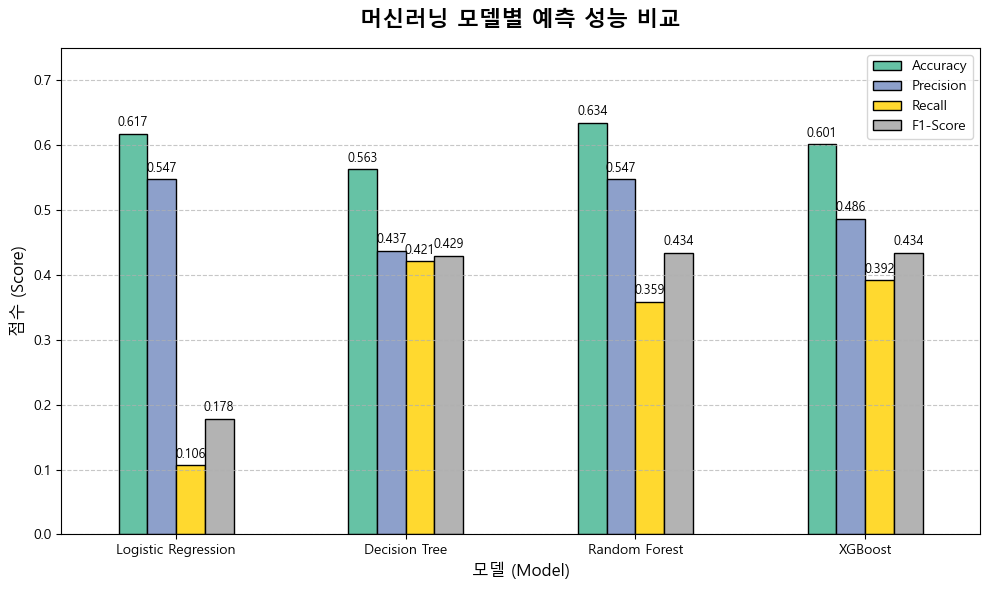

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# 0. 한글 폰트 설정 
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 1. 평가 지표들을 모아 데이터프레임화
metrics_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy, accuracy_dt, accuracy_rf, accuracy_xgb],
    'Precision': [precision, precision_dt, precision_rf, precision_xgb],
    'Recall': [recall, recall_dt, recall_rf, recall_xgb],
    'F1-Score': [f1, f1_dt, f1_rf, f1_xgb]
}
df_metrics = pd.DataFrame(metrics_data)
df_metrics.set_index('Model', inplace=True)

print("====== 📊 모델별 평가 지표 요약 표 ======")
display(df_metrics.round(4)) # 보기 좋게 소수점 4자리까지 출력

# 2. 막대 그래프 시각화 (Bar Chart)
ax = df_metrics.plot(kind='bar', figsize=(10, 6), rot=0, colormap='Set2', edgecolor='black')

plt.title('머신러닝 모델별 예측 성능 비교', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('모델 (Model)', fontsize=12)
plt.ylabel('점수 (Score)', fontsize=12)

plt.ylim(0, 0.75) 
plt.legend(loc='upper right') 
# ==========================================

plt.grid(axis='y', linestyle='--', alpha=0.7) # Y축 기준 점선 그리드 추가

# 막대 그래프 위에 수치 텍스트 표시
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()